Total experiments for regression: 4
Top 5 Experiments (regression)
               experiment_name  n_filters  dropout_rate  learning_rate  \
1  shallow_cnn_20260310_075032         64           0.4          0.001   
3  shallow_cnn_20260310_134103        128           0.4          0.001   
4  shallow_cnn_20260310_183435         64           0.4          0.001   
2  shallow_cnn_20260310_102422         64           0.4          0.001   

   batch_size   val_mae    val_r2                              notes  
1          32  0.289735  0.911963                 Smaller batch size  
3          64  0.320032  0.902779     increased filters and patience  
4         128  0.325677  0.899147  increased batch size and patience  
2          64  0.341138  0.894638                       baseline run  


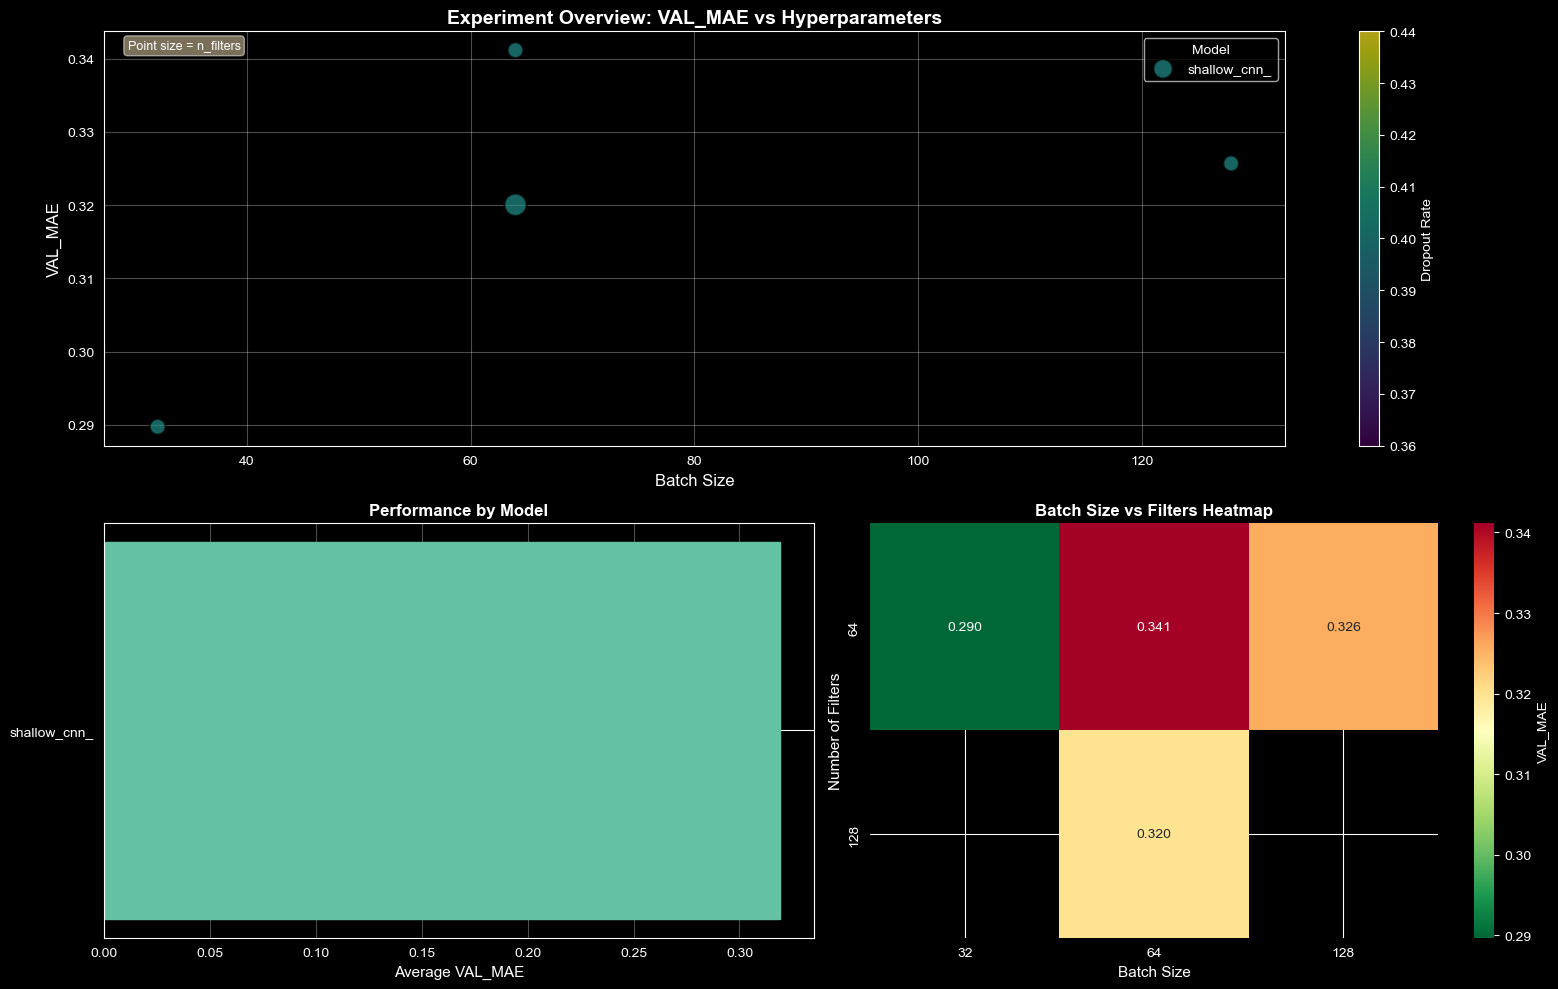


Last 5 experiments:

Regression Metric Summary Statistics:
        val_mae    val_r2
count  4.000000  4.000000
mean   0.319146  0.902132
std    0.021542  0.007351
min    0.289735  0.894638
25%    0.312458  0.898020
50%    0.322855  0.900963
75%    0.329543  0.905075
max    0.341138  0.911963


In [2]:
# Load experiments
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================================
# CONFIGURATION: Select task type to analyze
# ============================================================
TASK_TYPE = 'regression'  # Options: 'binary' or 'regression'
# ============================================================

df = pd.read_csv('../models/saved/experiments.csv')

# Filter by task type
df_filtered = df[df['task_type'] == TASK_TYPE].copy()
print(f"Total experiments for {TASK_TYPE}: {len(df_filtered)}")

if len(df_filtered) == 0:
    print(f"No {TASK_TYPE} experiments found!")
else:
    df_filtered.head()

# Cell 2: Best experiments
print("=" * 60)
print(f"Top 5 Experiments ({TASK_TYPE})")
print("=" * 60)

if TASK_TYPE == 'regression':
    best = df_filtered.sort_values('val_mae').head(5)
    print(best[['experiment_name', 'n_filters', 'dropout_rate',
                'learning_rate', 'batch_size', 'val_mae', 'val_r2', 'notes']])
    metric = 'val_mae'
    metric_cols = ['val_mae', 'val_r2']
else:  # binary
    best = df_filtered.sort_values('val_f1', ascending=False).head(5)
    print(best[['experiment_name', 'n_filters', 'dropout_rate',
                'learning_rate', 'batch_size', 'val_f1', 'val_accuracy', 'notes']])
    metric = 'val_f1'
    metric_cols = ['val_f1', 'val_accuracy', 'val_precision', 'val_recall']

# Cell 3: Visualizations
# Extract model name from experiment_name (e.g., 'shallow_cnn' or 'deep_cnn')
df_filtered['model'] = df_filtered['experiment_name'].str.extract(r'(^[a-z_]+)')[0]

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))

# 1. Scatter plot with multiple encodings (main plot)
ax1 = plt.subplot(2, 2, (1, 2))  # Top row, spanning 2 columns

# Get unique values for coloring and sizing
models = df_filtered['model'].unique()
colors = plt.cm.Set2(range(len(models)))
model_colors = dict(zip(models, colors))

for model in models:
    model_data = df_filtered[df_filtered['model'] == model]

    # Scatter: x=batch_size, y=metric, color=dropout_rate, size=n_filters
    scatter = ax1.scatter(
        model_data['batch_size'],
        model_data[metric],
        s=model_data['n_filters'] * 2,  # Scale filter count to point size
        c=model_data['dropout_rate'],
        cmap='viridis',
        alpha=0.7,
        edgecolors='black',
        linewidth=1.5,
        marker='o' if 'shallow' in model else 's',  # Circle for shallow, square for deep
        label=model
    )

ax1.set_xlabel('Batch Size', fontsize=12)
ax1.set_ylabel(metric.upper(), fontsize=12)
ax1.set_title(f'Experiment Overview: {metric.upper()} vs Hyperparameters', fontsize=14, fontweight='bold')
ax1.legend(title='Model', loc='best')
ax1.grid(True, alpha=0.3)

# Add colorbar for dropout rate
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Dropout Rate', fontsize=10)

# Add text annotation for filter sizes
ax1.text(0.02, 0.98, 'Point size = n_filters',
         transform=ax1.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Bar chart: Average metric by model
ax2 = plt.subplot(2, 2, 3)
model_avg = df_filtered.groupby('model')[metric].mean().sort_values()
bars = ax2.barh(range(len(model_avg)), model_avg.values)
ax2.set_yticks(range(len(model_avg)))
ax2.set_yticklabels(model_avg.index)
ax2.set_xlabel(f'Average {metric.upper()}', fontsize=11)
ax2.set_title('Performance by Model', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Color bars by model
for i, (model_name, bar) in enumerate(zip(model_avg.index, bars)):
    bar.set_color(model_colors.get(model_name, 'gray'))

# 3. Heatmap: batch_size vs n_filters (for the best model)
ax3 = plt.subplot(2, 2, 4)

if len(df_filtered) >= 3:  # Only create heatmap if enough data
    # Pivot table for heatmap
    pivot = df_filtered.pivot_table(
        values=metric,
        index='n_filters',
        columns='batch_size',
        aggfunc='mean'
    )

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r' if 'mae' in metric else 'RdYlGn',
                ax=ax3, cbar_kws={'label': metric.upper()})
    ax3.set_title('Batch Size vs Filters Heatmap', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Batch Size', fontsize=11)
    ax3.set_ylabel('Number of Filters', fontsize=11)
else:
    ax3.text(0.5, 0.5, 'Not enough experiments\nfor heatmap\n(need ≥3)',
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Batch Size vs Filters Heatmap', fontsize=12, fontweight='bold')
    ax3.axis('off')

plt.tight_layout()
plt.show()

# Cell 4: Recent experiments
print("\nLast 5 experiments:")
df_filtered.tail(5)[['experiment_name', 'timestamp'] + metric_cols + ['notes']]

# Cell 5: Export summary - only show metric columns
print(f"\n{TASK_TYPE.capitalize()} Metric Summary Statistics:")
available_metrics = [col for col in metric_cols if col in df_filtered.columns]
if available_metrics:
    summary = df_filtered[available_metrics].describe()
    print(summary)
else:
    print("No validation metrics found")